<a href="https://colab.research.google.com/github/SerbC/ELM_2026/blob/main/ELM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# PLAN

# Import data                   DONE
# Verify data integrity
# Split data train/test/[val]   DONE
# Data pre-processing:
#   * Image Normalisation
#   * Hand segmentation
#   * Hand extraction
# Feature extraction
# Classification

# PR curve / confusion matrix

In [31]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob
import random

In [5]:
base_path = "/content/drive/MyDrive/fac/Laborator/Images/"
file_path_arr = []
for i in range(4):
  file_path_arr.append(glob.glob(base_path+str(i)+"/*jpg"))
print("All images")
print(file_path_arr)
print("Firts folder")
print(file_path_arr[0])
print("Firts image")
print(file_path_arr[0][0])


All images
[['/content/drive/MyDrive/fac/Laborator/Images/0/0.jpg', '/content/drive/MyDrive/fac/Laborator/Images/0/1.jpg', '/content/drive/MyDrive/fac/Laborator/Images/0/2.jpg', '/content/drive/MyDrive/fac/Laborator/Images/0/3.jpg', '/content/drive/MyDrive/fac/Laborator/Images/0/4.jpg', '/content/drive/MyDrive/fac/Laborator/Images/0/5.jpg', '/content/drive/MyDrive/fac/Laborator/Images/0/6.jpg', '/content/drive/MyDrive/fac/Laborator/Images/0/7.jpg', '/content/drive/MyDrive/fac/Laborator/Images/0/8.jpg', '/content/drive/MyDrive/fac/Laborator/Images/0/9.jpg'], ['/content/drive/MyDrive/fac/Laborator/Images/1/0.jpg', '/content/drive/MyDrive/fac/Laborator/Images/1/1.jpg', '/content/drive/MyDrive/fac/Laborator/Images/1/2.jpg', '/content/drive/MyDrive/fac/Laborator/Images/1/3.jpg', '/content/drive/MyDrive/fac/Laborator/Images/1/4.jpg', '/content/drive/MyDrive/fac/Laborator/Images/1/5.jpg', '/content/drive/MyDrive/fac/Laborator/Images/1/6.jpg', '/content/drive/MyDrive/fac/Laborator/Images/1/7.j

In [41]:
random.seed(42)

In [42]:
image_index_arr = random.sample(range(0,9),7)
print(image_index_arr)

[1, 0, 5, 2, 8, 4, 7]


In [32]:
train_image_path = []
test_image_path = []

for hand_class in file_path_arr:
  tmp_train = []
  tmp_test = []
  for i in range(10):
    if i not in image_index_arr:
      tmp_test.append(hand_class[i])
    else:
      tmp_train.append(hand_class[i])
  train_image_path.append(tmp_train)
  test_image_path.append(tmp_test)

print(np.shape(train_image_path))
print(np.shape(test_image_path))


(4, 7)
(4, 3)


In [43]:
train_images = []
test_images = []

for cls in train_image_path:
  t = []
  for path in cls:
    t.append(cv2.imread(path))
  train_images.append(t)

for cls in test_image_path:
  t = []
  for i in cls:
    t.append(cv2.imread(i))
  test_images.append(t)

print(np.shape(train_images))
print(np.shape(test_images))

(4, 7, 4032, 1908, 3)
(4, 3, 4032, 1908, 3)


(<Figure size 640x480 with 1 Axes>,
 <matplotlib.image.AxesImage at 0x78661911be30>)

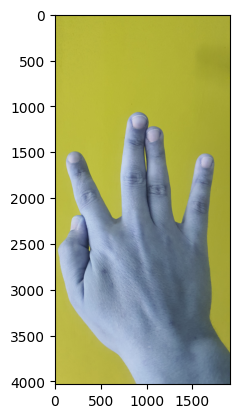

In [44]:
plt.figure(), plt.imshow(train_images[0][0])